# Spectrum analysis

This notebook computes or loads a fixed spectrum, then runs the elbow, energy, manual, and full-dimension selectors independently. Saved spectra can be reused when thresholds or manual scales change, so SVD does not need to run again.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import torch

sys.path.append("./cluster_anlys")

from spectrum_pipeline import (
    ElbowSelector,
    EnergyThresholdSelector,
    FullDimensionSelector,
    ManualScaleSelector,
    SVDAnalyzer,
    SpectralAnalysisResult,
    load_spectrum_result,
    merge_scale_selections,
    plot_spectrum_diagnostics,
    print_spectrum_summary,
    save_analysis_summary,
    save_candidate_scale_set,
    save_spectrum_result,
)


## Configuration

Set `RECOMPUTE_SPECTRUM` to `True` when generating the fixed spectra for the first time. After saving them, set it to `False` to rerun only scale selection.


In [2]:
RECOMPUTE_SPECTRUM = False
SPECTRUM_ROOT = Path("res/spectrum_analysis")
ENERGY_THRESHOLDS = (0.5, 0.75, 0.9, 0.95)
ELBOW_PARAMETERS = {
    "use_squared": True,
    "smoothing": None,
    "smooth_window": 51,
    "smooth_polyorder": 3,
    "take_abs_curvature": False,
    "top_k": 4,
    "min_gap": 128,
    "use_abs_for_peak_ranking": True,
    "prominence": None,
}

MODEL_CONFIGS = [
    {
        "model_name": "mistralai/Mistral-7B-v0.1",
        "space_name": "output_proj",
        "matrix_path": Path("mistralai/Mistral-7B-v0.1/tensors/output_proj.pt"),
        "manual_scales": (),
        "expected_scales": [5, 142, 997, 2084, 3031, 3459, 3938, 4088, 4096],
    },
    {
        "model_name": "mistralai/Mixtral-8x7B-v0.1",
        "space_name": "output_proj",
        "matrix_path": Path("mistralai/Mixtral-8x7B-v0.1/tensors/output_proj.pt"),
        "manual_scales": (),
        "expected_scales": [8, 158, 1111, 2156, 3052, 3457, 3957, 4093, 4096],
    },
    {
        "model_name": "gpt-oss",
        "space_name": "output_proj",
        "matrix_path": Path("gpt-oss/tensors/output_proj.pt"),
        "manual_scales": (),
        "expected_scales": [6, 182, 466, 739, 1591, 2264, 2532, 2868, 2880],
    },
]


def safe_model_name(model_name):
    return model_name.replace("/", "_")


## Fixed spectrum

This section handles only the SVD spectrum. The saved `SpectrumResult` contains the curve, scale axis, energy measures, and input metadata, but no threshold-specific selection configuration.


In [3]:
def compute_or_load_spectrum(config):
    model_name = config["model_name"]
    output_dir = SPECTRUM_ROOT / safe_model_name(model_name)
    spectrum_path = output_dir / "spectrum_result.npz"

    if not RECOMPUTE_SPECTRUM:
        if not spectrum_path.exists():
            raise FileNotFoundError(
                f"Missing saved spectrum: {spectrum_path}. "
                "Set RECOMPUTE_SPECTRUM=True and run this notebook once."
            )
        spectrum = load_spectrum_result(spectrum_path)
        print(f"Loaded spectrum for {model_name}: {spectrum_path}")
        return spectrum

    matrix_path = config["matrix_path"]
    embedding_matrix = torch.load(matrix_path, map_location="cpu")
    embedding_matrix = embedding_matrix.to(torch.float32)
    print(f"Loaded matrix for {model_name}: shape={tuple(embedding_matrix.shape)}")

    analyzer = SVDAnalyzer(svd_mode="full", device=None)
    spectrum = analyzer.analyze(
        embedding_matrix,
        metadata={
            "model_name": model_name,
            "space_name": config["space_name"],
            "matrix_path": str(matrix_path),
            "centered": False,
        },
    )
    save_spectrum_result(spectrum, spectrum_path)
    print(f"Saved spectrum for {model_name}: {spectrum_path}")
    del embedding_matrix
    return spectrum


spectrum_results = {
    config["model_name"]: compute_or_load_spectrum(config)
    for config in MODEL_CONFIGS
}


Loaded matrix for mistralai/Mistral-7B-v0.1: shape=(32000, 4096)


Saved spectrum for mistralai/Mistral-7B-v0.1: res/spectrum_analysis/mistralai_Mistral-7B-v0.1/spectrum_result.npz
Loaded matrix for mistralai/Mixtral-8x7B-v0.1: shape=(32000, 4096)


Saved spectrum for mistralai/Mixtral-8x7B-v0.1: res/spectrum_analysis/mistralai_Mixtral-8x7B-v0.1/spectrum_result.npz


Loaded matrix for gpt-oss: shape=(201088, 2880)


Saved spectrum for gpt-oss: res/spectrum_analysis/gpt-oss/spectrum_result.npz


## Candidate scale selection

The elbow minimum gap constrains only elbow peaks. Energy, manual, and full-dimension scales are selected independently and then merged through a provenance-aware union.


In [4]:
def select_candidate_scales(config, spectrum):
    elbow_selection = ElbowSelector(**ELBOW_PARAMETERS).select(spectrum)
    energy_selection = EnergyThresholdSelector(
        thresholds=ENERGY_THRESHOLDS,
        name="energy",
    ).select(spectrum)
    manual_selection = ManualScaleSelector(
        scales=config["manual_scales"],
        name="manual",
    ).select(spectrum)
    full_selection = FullDimensionSelector(name="full_dimension").select(spectrum)

    selections = {
        "elbow": elbow_selection,
        "energy": energy_selection,
        "manual": manual_selection,
        "full_dimension": full_selection,
    }
    candidate_scales = merge_scale_selections(
        selections.values(),
        full_dimension=full_selection.selected_scales[0],
        metadata={
            "model_name": config["model_name"],
            "space_name": config["space_name"],
            "scope": "main",
        },
    )
    return SpectralAnalysisResult(
        spectrum=spectrum,
        selections=selections,
        candidate_scales=candidate_scales,
    )


analysis_results = {
    config["model_name"]: select_candidate_scales(
        config,
        spectrum_results[config["model_name"]],
    )
    for config in MODEL_CONFIGS
}


## Validation and outputs

This section validates the nine refactored main-study scales for each model and saves the selection summary, candidate-scale provenance table, and diagnostic figure.



mistralai/Mistral-7B-v0.1
=== Spectrum Summary ===

Top singular values:
   1  singular_value=16.138685  energy_ratio=0.110923
   2  singular_value=2.314828  energy_ratio=0.002282
   3  singular_value=2.193521  energy_ratio=0.002049
   4  singular_value=2.149795  energy_ratio=0.001968
   5  singular_value=1.885114  energy_ratio=0.001513
   6  singular_value=1.830650  energy_ratio=0.001427
   7  singular_value=1.684758  energy_ratio=0.001209
   8  singular_value=1.629061  energy_ratio=0.001130
   9  singular_value=1.580443  energy_ratio=0.001064
  10  singular_value=1.532073  energy_ratio=0.001000

Energy thresholds:
threshold=0.5000  scale= 997  cumulative_energy=0.5001
threshold=0.7500  scale=2084  cumulative_energy=0.7501
threshold=0.9000  scale=3031  cumulative_energy=0.9000
threshold=0.9500  scale=3459  cumulative_energy=0.9500

Elbow scales:
[5, 142, 3938, 4088]

Candidate scales:
[5, 142, 997, 2084, 3031, 3459, 3938, 4088, 4096]

Scale provenance:
 scale        sources  is_full_

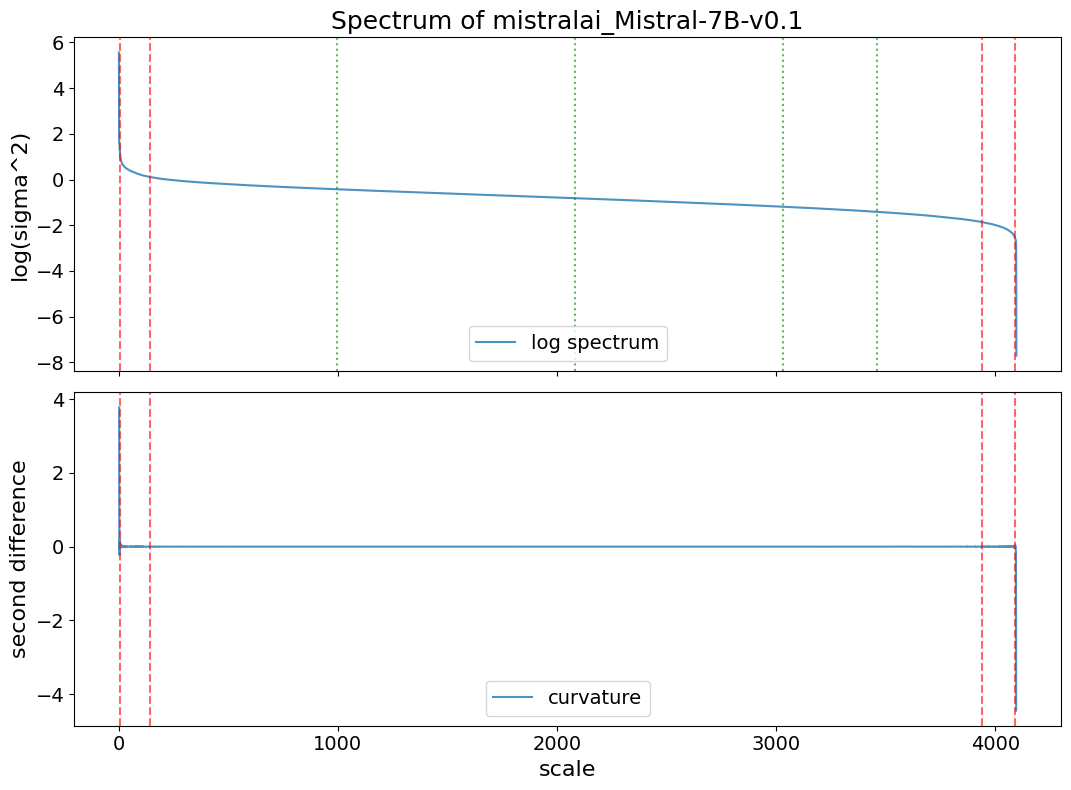


mistralai/Mixtral-8x7B-v0.1
=== Spectrum Summary ===

Top singular values:
   1  singular_value=26.279310  energy_ratio=0.059172
   2  singular_value=7.141376  energy_ratio=0.004370
   3  singular_value=5.361146  energy_ratio=0.002463
   4  singular_value=4.929482  energy_ratio=0.002082
   5  singular_value=4.589211  energy_ratio=0.001805
   6  singular_value=4.346421  energy_ratio=0.001619
   7  singular_value=4.227377  energy_ratio=0.001531
   8  singular_value=3.781553  energy_ratio=0.001225
   9  singular_value=3.694566  energy_ratio=0.001170
  10  singular_value=3.587061  energy_ratio=0.001102

Energy thresholds:
threshold=0.5000  scale=1111  cumulative_energy=0.5002
threshold=0.7500  scale=2156  cumulative_energy=0.7502
threshold=0.9000  scale=3052  cumulative_energy=0.9000
threshold=0.9500  scale=3457  cumulative_energy=0.9500

Elbow scales:
[8, 158, 3957, 4093]

Candidate scales:
[8, 158, 1111, 2156, 3052, 3457, 3957, 4093, 4096]

Scale provenance:
 scale        sources  is_fu

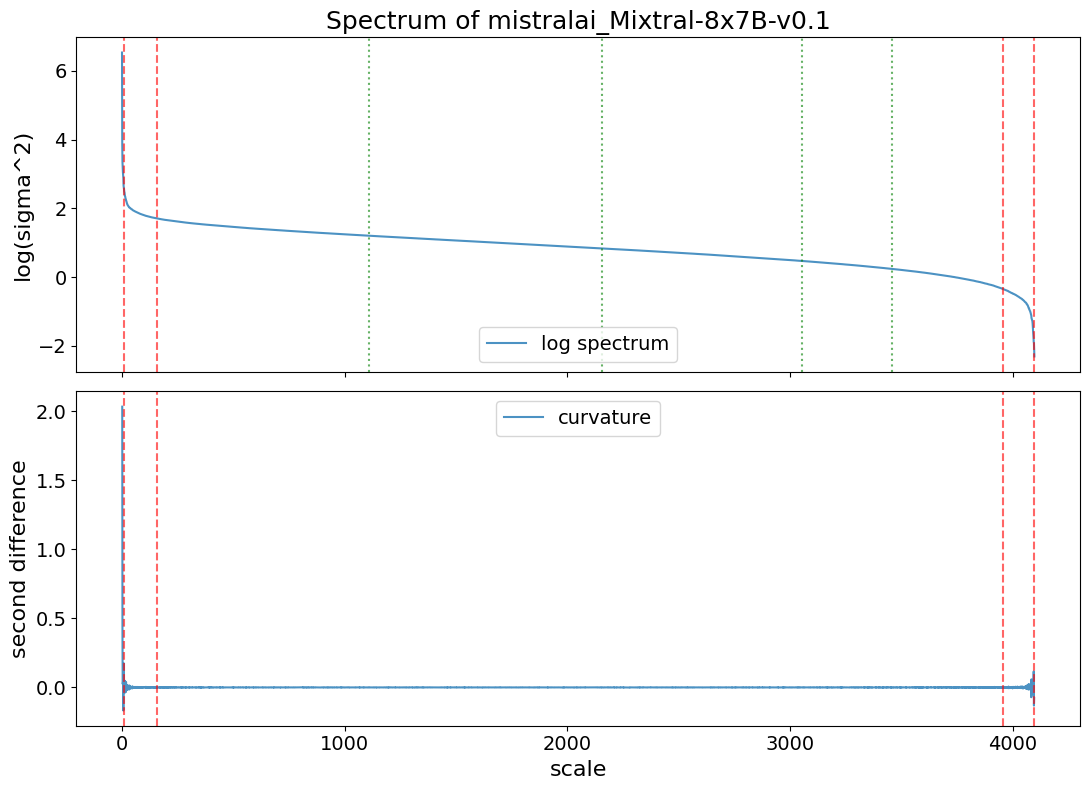


gpt-oss
=== Spectrum Summary ===

Top singular values:
   1  singular_value=22.566792  energy_ratio=0.031373
   2  singular_value=11.849593  energy_ratio=0.008650
   3  singular_value=9.884230  energy_ratio=0.006019
   4  singular_value=9.208690  energy_ratio=0.005224
   5  singular_value=8.352577  energy_ratio=0.004298
   6  singular_value=7.321667  energy_ratio=0.003302
   7  singular_value=7.226995  energy_ratio=0.003218
   8  singular_value=7.009602  energy_ratio=0.003027
   9  singular_value=6.786899  energy_ratio=0.002838
  10  singular_value=6.564515  energy_ratio=0.002655

Energy thresholds:
threshold=0.5000  scale= 739  cumulative_energy=0.5002
threshold=0.7500  scale=1591  cumulative_energy=0.7501
threshold=0.9000  scale=2264  cumulative_energy=0.9002
threshold=0.9500  scale=2532  cumulative_energy=0.9502

Elbow scales:
[6, 182, 466, 2868]

Candidate scales:
[6, 182, 466, 739, 1591, 2264, 2532, 2868, 2880]

Scale provenance:
 scale        sources  is_full_dimension
     6   

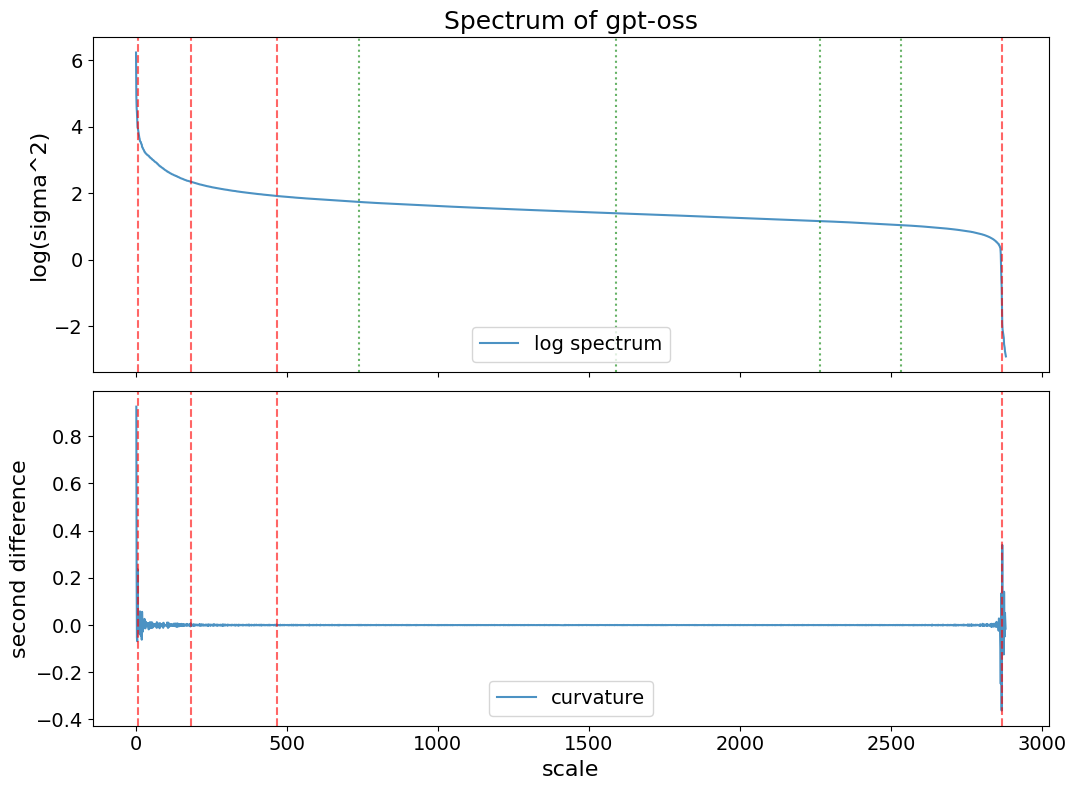

,model_name,scale,sources,is_full_dimension
0,mistralai/Mistral-7B-v0.1,5,elbow,False
1,mistralai/Mistral-7B-v0.1,142,elbow,False
2,mistralai/Mistral-7B-v0.1,997,energy,False
3,mistralai/Mistral-7B-v0.1,2084,energy,False
4,mistralai/Mistral-7B-v0.1,3031,energy,False
5,mistralai/Mistral-7B-v0.1,3459,energy,False
6,mistralai/Mistral-7B-v0.1,3938,elbow,False
7,mistralai/Mistral-7B-v0.1,4088,elbow,False
8,mistralai/Mistral-7B-v0.1,4096,full_dimension,True
9,mistralai/Mixtral-8x7B-v0.1,8,elbow,False


In [5]:
candidate_tables = []

for config in MODEL_CONFIGS:
    model_name = config["model_name"]
    result = analysis_results[model_name]
    expected_scales = config["expected_scales"]
    if result.candidate_dims != expected_scales:
        raise AssertionError(
            f"Candidate scale mismatch for {model_name}: "
            f"expected={expected_scales}, observed={result.candidate_dims}"
        )

    output_dir = SPECTRUM_ROOT / safe_model_name(model_name)
    save_analysis_summary(result, output_dir / "analysis_summary.json")
    save_candidate_scale_set(
        result.candidate_scales,
        output_dir / "candidate_scales.json",
    )

    candidate_frame = result.candidate_scales.to_frame()
    candidate_frame.insert(0, "model_name", model_name)
    candidate_frame.to_csv(output_dir / "candidate_scales.csv", index=False)
    candidate_tables.append(candidate_frame)

    print()
    print("=" * 80)
    print(model_name)
    print_spectrum_summary(result, top_n=10)
    plot_spectrum_diagnostics(
        result,
        model_name=model_name,
        xscale="linear",
        out_dir=output_dir,
    )

all_candidate_scales = pd.concat(candidate_tables, ignore_index=True)
all_candidate_scales


## Legacy experimental cells

The following content comes from the non-spectrum experimental section of the old notebook. The existing logic is retained in non-executable raw cells and is not part of the new spectrum pipeline execution path.
